# Model — Price per m²
Predicting `price_per_square_meter` (PLN/m²) using tree-based and linear models. 

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb


## Preparing for Modeling

In [ ]:
df = pd.read_excel('../data/abt.xlsx')

# Drop low-signal features identified in EDA
cols_to_drop = ['rooms']#['floor', 'material', 'market']

X = df.drop(columns=['price_per_square_meter']).drop(columns=cols_to_drop)
y = df['price_per_square_meter']

# Categorical = one-hot encoded columns (material_ / district_ prefixes)
categorical_cols = [c for c in X.columns if c.startswith('material_') or c.startswith('district_')]
numerical_cols   = X.columns.difference(categorical_cols).tolist()

X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.15, random_state=42)

print(f"train={len(X_train)}, holdout={len(X_holdout)}, features={X_train.shape[1]}")
print(f"categorical={categorical_cols}")
print(f"numerical={numerical_cols}")


train=6875, holdout=1214, features=20
categorical=['material_group_brick', 'material_group_modern', 'material_group_other', 'material_group_prefab', 'district_group_Bielany_Bemowo', 'district_group_Ochota_Mokotów', 'district_group_Rembertów_Wawer_Białołęka', 'district_group_Targówek_Ursus', 'district_group_Ursynów_Praga Północ', 'district_group_Wilanów_Wola', 'district_group_Włochy_Praga Południe', 'district_group_Żoliborz_Śródmieście']
numerical=['building_age', 'dist_to_center', 'dist_to_metro', 'floor', 'market', 'river_side', 'rooms', 'surface']


In [43]:
preprocess = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', 'passthrough', numerical_cols),
])

# lasso needs scaled numerics — separate preprocessor
preprocess_scaled = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', StandardScaler(), numerical_cols),
])


### Feature correlation with target

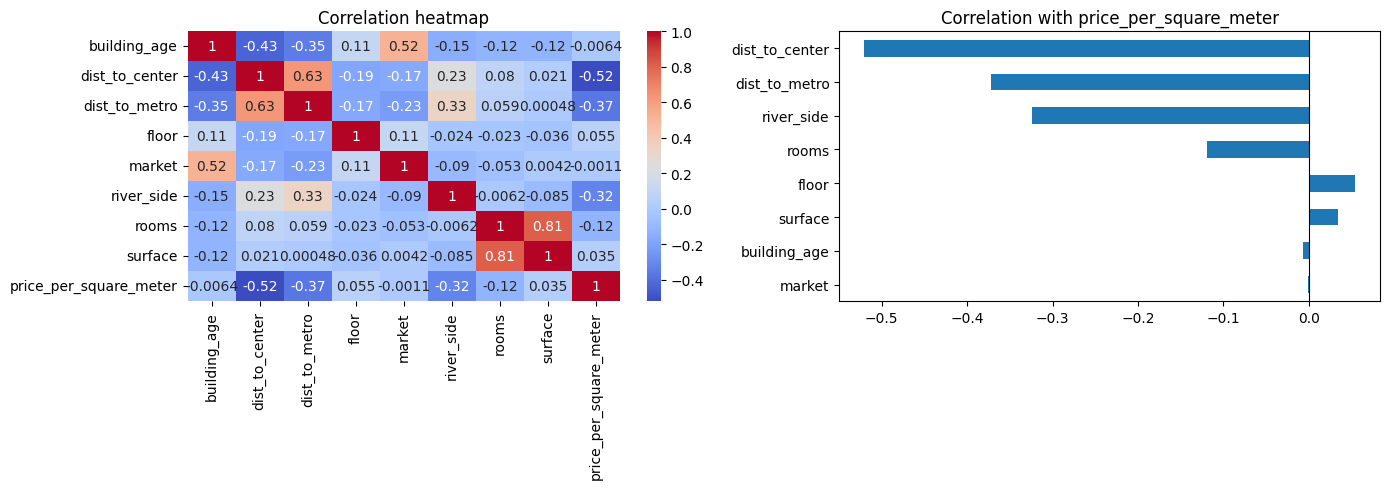

In [44]:
corr_cols = numerical_cols + ['price_per_square_meter']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation heatmap')

corr_target = df[corr_cols].corr()['price_per_square_meter'].drop('price_per_square_meter').sort_values(key=abs, ascending=True)
corr_target.plot(kind='barh', ax=axes[1])
axes[1].set_title('Correlation with price_per_square_meter')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


## Models

In [45]:
scoring = {
    'r2':   'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae':  'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)

def cv_summary(cv_results):
    df_cv = pd.DataFrame({
        'r2':   cv_results['test_r2'],
        'rmse': -cv_results['test_rmse'],
        'mae':  -cv_results['test_mae'],
        'mape': -cv_results['test_mape'],
    }).agg(['mean', 'std'])
    df_cv[['rmse', 'mae']] = df_cv[['rmse', 'mae']].round(1)
    df_cv[['r2']] = df_cv[['r2']].round(4)
    df_cv[['mape']] = df_cv[['mape']].round(4)
    return df_cv


### Baseline

In [46]:
baseline = Pipeline([
    ('preprocess', preprocess),
    ('model', DummyRegressor(strategy='mean')),
])

baseline_cv = cross_validate(baseline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary(baseline_cv)


,r2,rmse,mae,mape
mean,-0.0010,4378.7,3385.0,0.1939
std,0.0009,106.4,98.8,0.0078


### Decision Tree

In [47]:
dt_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeRegressor(random_state=42)),
])

dt_cv = cross_validate(dt_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary(dt_cv)


,r2,rmse,mae,mape
mean,0.5512,2927.1,1781.0,0.0988
std,0.0547,190.9,113.9,0.0067


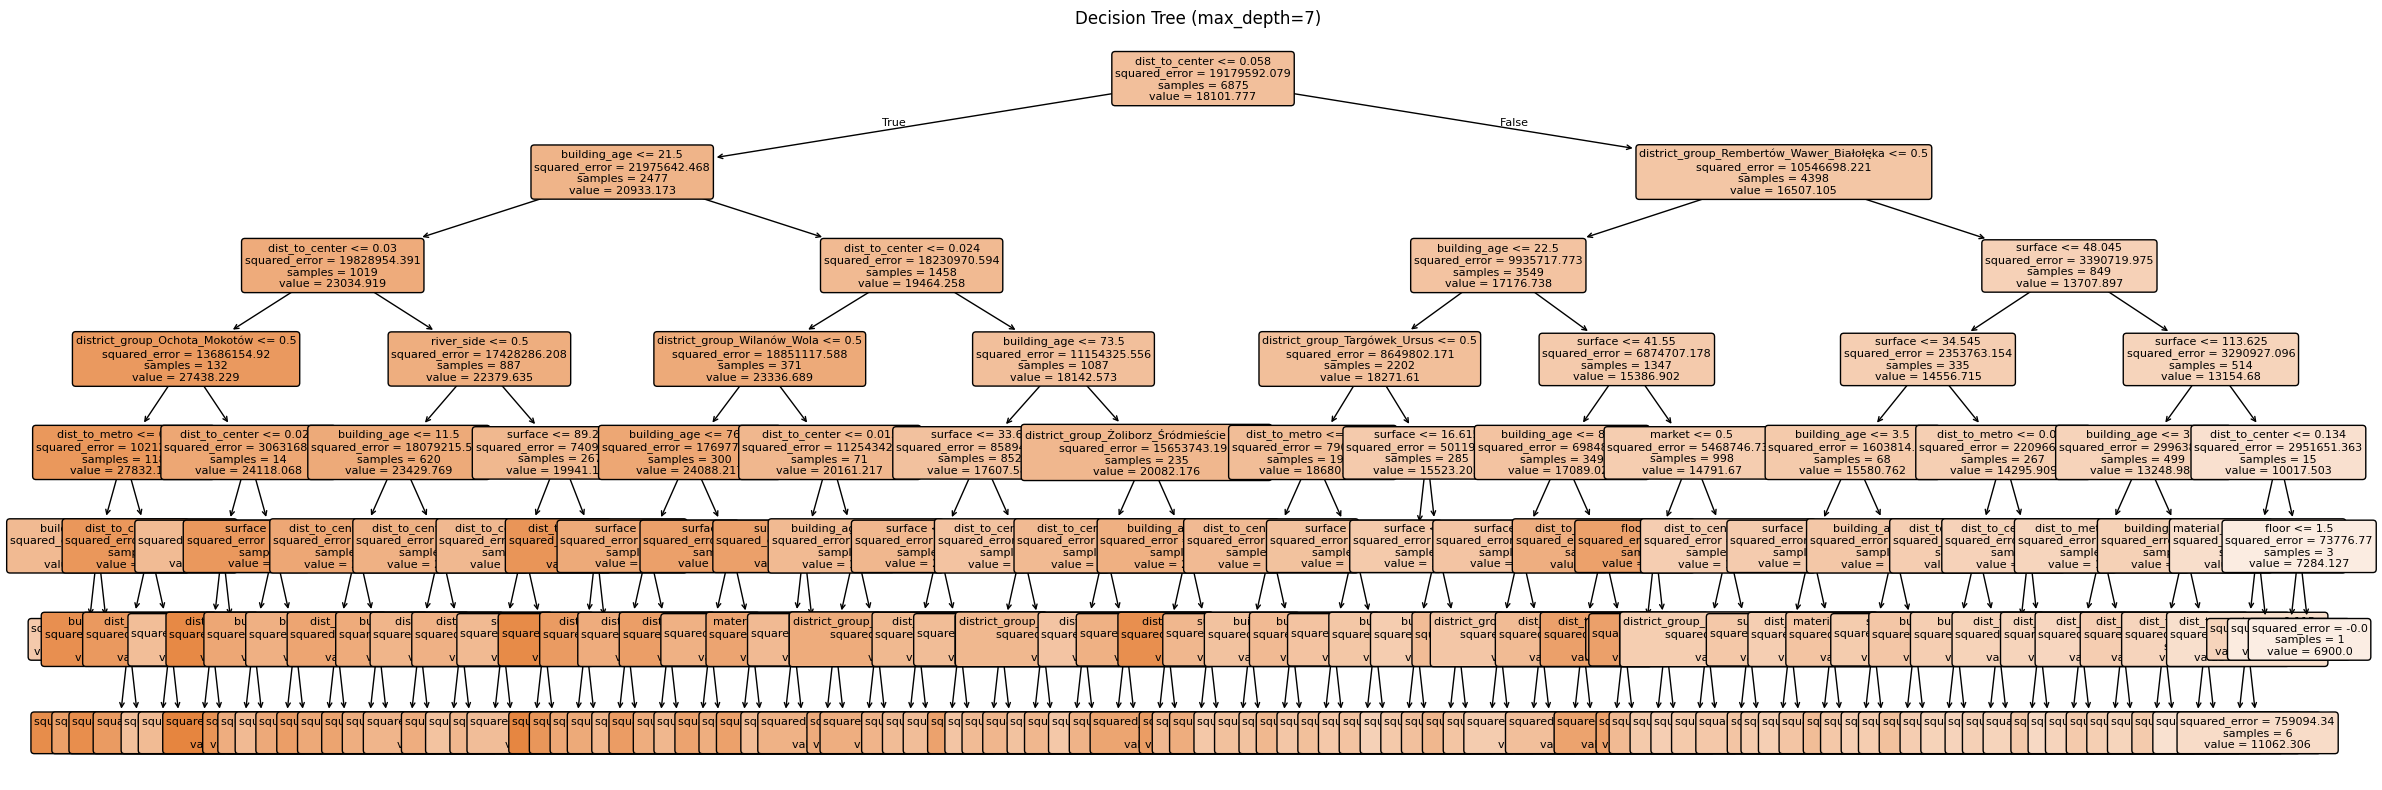

In [48]:
from sklearn.tree import plot_tree

# Fit a shallow tree for readability
dt_vis = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeRegressor(max_depth=7, random_state=42, min_impurity_decrease=0.09, ccp_alpha=0.001 )),
])
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    dt_vis.named_steps['model'],
    feature_names=categorical_cols + numerical_cols,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
plt.title('Decision Tree (max_depth=7)')
plt.tight_layout()
plt.show()


In [49]:
feature_names = categorical_cols + numerical_cols
tree_model = dt_vis.named_steps["model"]

used_feature_idx = tree_model.tree_.feature
used_feature_idx = used_feature_idx[used_feature_idx >= 0]  # exclude leaves

used_features = {feature_names[i] for i in used_feature_idx}
unused_features = [f for f in feature_names if f not in used_features]

print(f"Used features: {len(used_features)}/{len(feature_names)}")
print(f"Unused features: {len(unused_features)}")
pd.Series(unused_features, name="unused_feature")

Used features: 15/20
Unused features: 5


0                   material_group_modern
1                    material_group_other
2           district_group_Bielany_Bemowo
3    district_group_Włochy_Praga Południe
4                                   rooms
Name: unused_feature, dtype: object

### Hyperparameter tuning (RandomizedSearchCV)
Results below are used directly in the final RF and XGBoost pipelines.

In [50]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Random Forest
rf_param_grid = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': [None, 5, 30],
    'model__min_samples_split': randint(2, 5),
    'model__min_samples_leaf': [1, 3],
    'model__max_features': ['sqrt', 4, 5, 6],
    'model__bootstrap': [True, False],
}

_rf_base = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rf_grid = RandomizedSearchCV(
    _rf_base, rf_param_grid,
    n_iter=50, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=42,
)
rf_grid.fit(X_train, y_train)

print(f"RF best params:  {rf_grid.best_params_}")
print(f"RF CV RMSE:      {-rf_grid.best_score_:,.0f} PLN/m²")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
RF best params:  {'model__bootstrap': False, 'model__max_depth': None, 'model__max_features': 6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 427}
RF CV RMSE:      2,165 PLN/m²


In [51]:
# XGBoost
xgb_param_grid = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 9),
    'model__learning_rate': uniform(0.01, 0.19),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 6),
    'model__reg_alpha': uniform(0, 1.0),
    'model__reg_lambda': uniform(1.0, 4.0),
    'model__gamma': uniform(0, 0.5),
}

_xgb_base = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb.XGBRegressor(random_state=42)),
])

xgb_grid = RandomizedSearchCV(
    _xgb_base, xgb_param_grid,
    n_iter=50, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=42,
)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost best params:  {xgb_grid.best_params_}")
print(f"XGBoost CV RMSE:      {-xgb_grid.best_score_:,.0f} PLN/m²")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost best params:  {'model__colsample_bytree': np.float64(0.6367196263253767), 'model__gamma': np.float64(0.04707849413428006), 'model__learning_rate': np.float64(0.0691685287843459), 'model__max_depth': 8, 'model__min_child_weight': 4, 'model__n_estimators': 303, 'model__reg_alpha': np.float64(0.017161101831750236), 'model__reg_lambda': np.float64(4.053457692015644), 'model__subsample': np.float64(0.9227651908203118)}
XGBoost CV RMSE:      2,201 PLN/m²


### Random Forest

In [52]:
best_rf_params = {k.replace('model__', ''): v for k, v in rf_grid.best_params_.items()}

rf_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=1)),  # n_jobs=1 avoids nested parallelism
])

rf_cv = cross_validate(
    rf_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1,  # parallelism at CV level only
)
cv_summary(rf_cv)


,r2,rmse,mae,mape
mean,0.7573,2153.9,1344.0,0.0750
std,0.0282,157.4,97.7,0.0062


# Plot

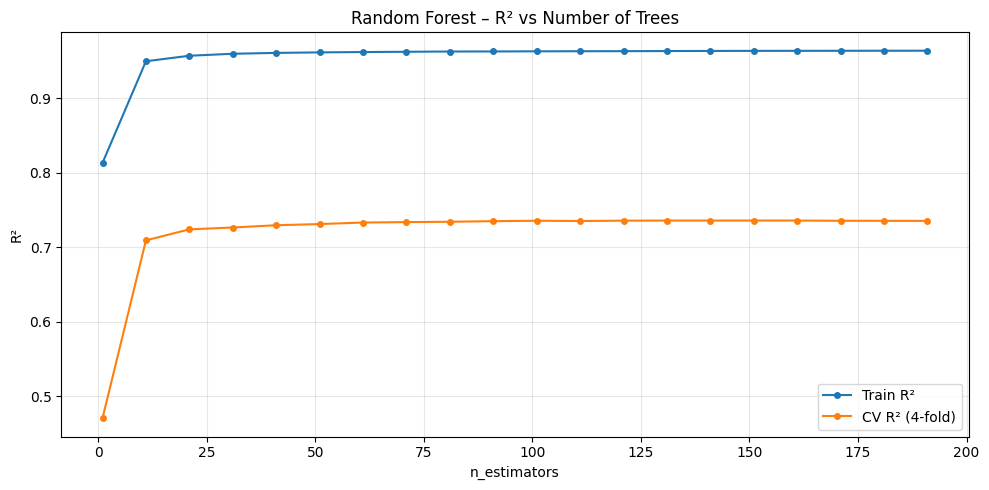

In [53]:

from sklearn.model_selection import cross_validate as _cv

n_estimators_range = list(range(1, 201, 10))
cv_r2, train_r2 = [], []

cv_opt = KFold(n_splits=4, shuffle=True, random_state=223)

for n in n_estimators_range:
    pipe = Pipeline([
        ("preprocess", preprocess),
        # n_jobs=1 on the estimator to avoid nested parallelism (WinError 1450)
        ("model", RandomForestRegressor(n_estimators=n, random_state=223, n_jobs=1)),
    ])
    res = _cv(pipe, X_train, y_train, cv=cv_opt,
              scoring="r2", return_train_score=True, n_jobs=-1)
    cv_r2.append(res["test_score"].mean())
    train_r2.append(res["train_score"].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_estimators_range, train_r2, label="Train R²", marker="o", markersize=4)
ax.plot(n_estimators_range, cv_r2, label="CV R² (4-fold)", marker="o", markersize=4)
ax.set_xlabel("n_estimators")
ax.set_ylabel("R²")
ax.set_title("Random Forest – R² vs Number of Trees")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### XGBoost

In [54]:
best_xgb_params = {k.replace('model__', ''): v for k, v in xgb_grid.best_params_.items()}

xgb_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb.XGBRegressor(**best_xgb_params, random_state=42)),
])

xgb_cv = cross_validate(
    xgb_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, return_estimator=True, n_jobs=-1,
)
cv_summary(xgb_cv)


,r2,rmse,mae,mape
mean,0.7497,2188.1,1435.4,0.0803
std,0.0245,135.7,81.1,0.0055


### Lasso

In [55]:
lasso_pipeline = Pipeline([
    ('preprocess', preprocess_scaled),
    ('model', Lasso(alpha=1.0, max_iter=10000, random_state=42)),
])

lasso_cv = cross_validate(lasso_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary(lasso_cv)



,r2,rmse,mae,mape
mean,0.4791,3159.0,2316.9,0.1298
std,0.0135,104.8,50.3,0.0042


In [56]:
import joblib
from sklearn.base import clone
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Save unfitted pipeline definitions so 05_assess can load them directly.
# This ensures assessment always uses the exact same hyperparameters defined here.
joblib.dump(clone(baseline),        MODELS_DIR / "baseline_pipeline.pkl")
joblib.dump(clone(dt_pipeline),     MODELS_DIR / "dt_pipeline.pkl")
joblib.dump(clone(rf_pipeline),     MODELS_DIR / "rf_pipeline.pkl")
joblib.dump(clone(xgb_pipeline),    MODELS_DIR / "xgb_pipeline.pkl")
joblib.dump(clone(lasso_pipeline),  MODELS_DIR / "lasso_pipeline.pkl")
print("All pipeline definitions saved to models/")

All pipeline definitions saved to models/
